# Analytic $P_s(\alpha_0, d, \kappa)$ fit: validation on the released scan table

The template and the **single declared coefficient record** live in the maintained
package (`vcdm_genesis.fit`, `data/fit_coefficients.json`):

$$\ln S_{\mathcal R}^{\rm fit} = -\ln(4\pi^2\alpha_0) - \frac{2(1+d)}{d} + \frac{2J(d,\kappa)}{d} + c_0 + c_1 d + q\,\ln C_{\nu_*}.$$

`Ps` in `genesis_scan_table.csv` is the dimensionless power $S_{\mathcal R}=\tau_B^2 M_{\rm Pl}^2\mathcal P_{\mathcal R}$
at the endpoint $x_f=10^{-7}$. The verification set holds out complete $(d,\kappa)$ pairs
(all $\alpha_0$ values together; seed 1234, 80 percent training).

All errors below are **relative to the stored numerical table** (table-relative fitting error);
they are not integration-error estimates of the underlying histories (see `docs/VALIDATION.md`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vcdm_genesis import fit

CSV_PATH = Path("genesis_scan_table.csv")
COEFFS = fit.load_coefficients()          # data/fit_coefficients.json
TRAIN_FRAC, SEED = 0.80, 1234
print({k: COEFFS[k] for k in ("c0", "c1", "q", "status")})

{'c0': 0.0167018906314, 'c1': -0.283027102799, 'q': 1.31920847627, 'status': 'released'}


In [2]:
df = pd.read_csv(CSV_PATH, usecols=["alpha", "d", "kappa", "Ps"], float_precision="round_trip")
train_mask = fit.split_by_d_kappa(df["d"].to_numpy(), df["kappa"].to_numpy(), train_frac=TRAIN_FRAC, seed=SEED)
train, verify = df[train_mask], df[~train_mask]
print(f"Loaded rows: {len(df):,}  training: {len(train):,}  verification: {len(verify):,}")

Loaded rows: 512,000  training: 409,600  verification: 102,400


In [3]:
def stats(part):
    s = fit.evaluate_fit(part["alpha"].to_numpy(), part["d"].to_numpy(), part["kappa"].to_numpy(), part["Ps"].to_numpy(), COEFFS)
    return {"mean error (%)": s["mean_abs_rel_percent"], "median error (%)": 100 * s["median_abs_rel"],
            "99th percentile (%)": 100 * s["q99_abs_rel"], "max error (%)": s["max_abs_rel_percent"],
            "max at (alpha0, d, kappa)": (s["argmax"]["alpha0"], s["argmax"]["d"], s["argmax"]["kappa"])}

pd.DataFrame({"training": stats(train), "verification": stats(verify), "full grid": stats(df)})

,training,verification,full grid
mean error (%),0.108564,0.109237,0.108699
median error (%),0.091998,0.093461,0.092237
99th percentile (%),0.299553,0.304681,0.300401
max error (%),0.328417,0.327623,0.328417
"max at (alpha0, d, kappa)","(7.692649574879162e-22, 0.17215189873417724, 0...","(7.692649574879162e-22, 0.16835443037974684, 0...","(7.692649574879162e-22, 0.17215189873417724, 0..."


## Optional refit (not run by default)

The released coefficients are fixed; the minimax optimum of the released training set is recorded in the coefficient record for reference.
Set `REFIT = True` to solve the minimax linear programme on the training groups and compare.

In [4]:
REFIT = False
if REFIT:
    new_coeffs, t = fit.minimax_fit(train["alpha"].to_numpy(), train["d"].to_numpy(), train["kappa"].to_numpy(), train["Ps"].to_numpy())
    print("refit:", new_coeffs, "max |log error| on training:", t)
    print("released:", {k: COEFFS[k] for k in ("c0", "c1", "q")})

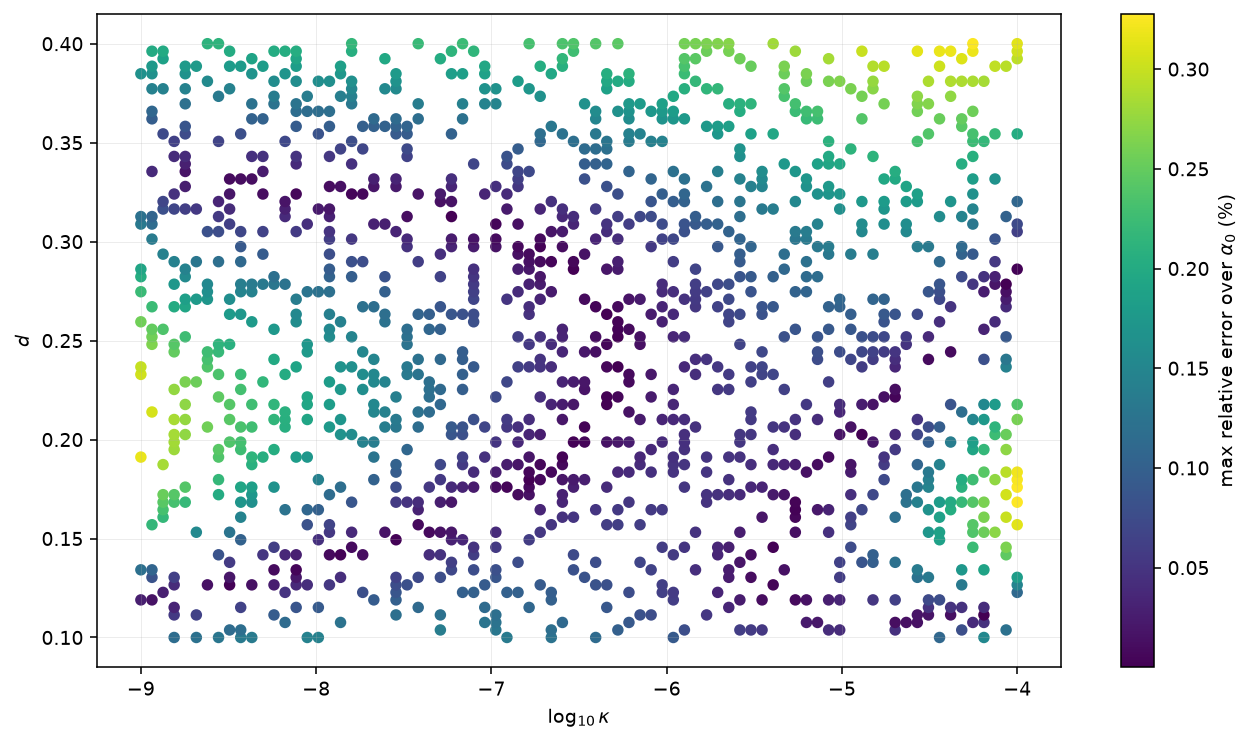

In [5]:
def pair_loss_table(part):
    tmp = part[["alpha", "d", "kappa", "Ps"]].copy()
    log_pred = fit.log_S_R_fit(tmp["alpha"].to_numpy(), tmp["d"].to_numpy(), tmp["kappa"].to_numpy(), COEFFS)
    tmp["loss_percent"] = 100.0 * np.abs(np.expm1(log_pred - np.log(tmp["Ps"].to_numpy())))
    # aggregation: maximum over the 80 alpha0 values of each (d, kappa) pair, in percent
    return tmp.groupby(["d", "kappa"], as_index=False)["loss_percent"].max().assign(log10_kappa=lambda x: np.log10(x["kappa"]))


def plot_verification_loss_heatmap(pair_loss, output_path=None):
    fig, ax = plt.subplots(figsize=(9.5, 5.4), dpi=140)
    sc = ax.scatter(pair_loss["log10_kappa"], pair_loss["d"], c=pair_loss["loss_percent"], s=24)
    fig.colorbar(sc, ax=ax).set_label("max relative error over $\\alpha_0$ (%)")
    ax.set_xlabel(r"$\log_{10}\kappa$"); ax.set_ylabel(r"$d$"); ax.grid(True, linewidth=0.3, alpha=0.4)
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")
    return fig, ax


verify_pair_loss = pair_loss_table(verify)
fig, ax = plot_verification_loss_heatmap(verify_pair_loss, output_path="verification_loss.png")
plt.show()

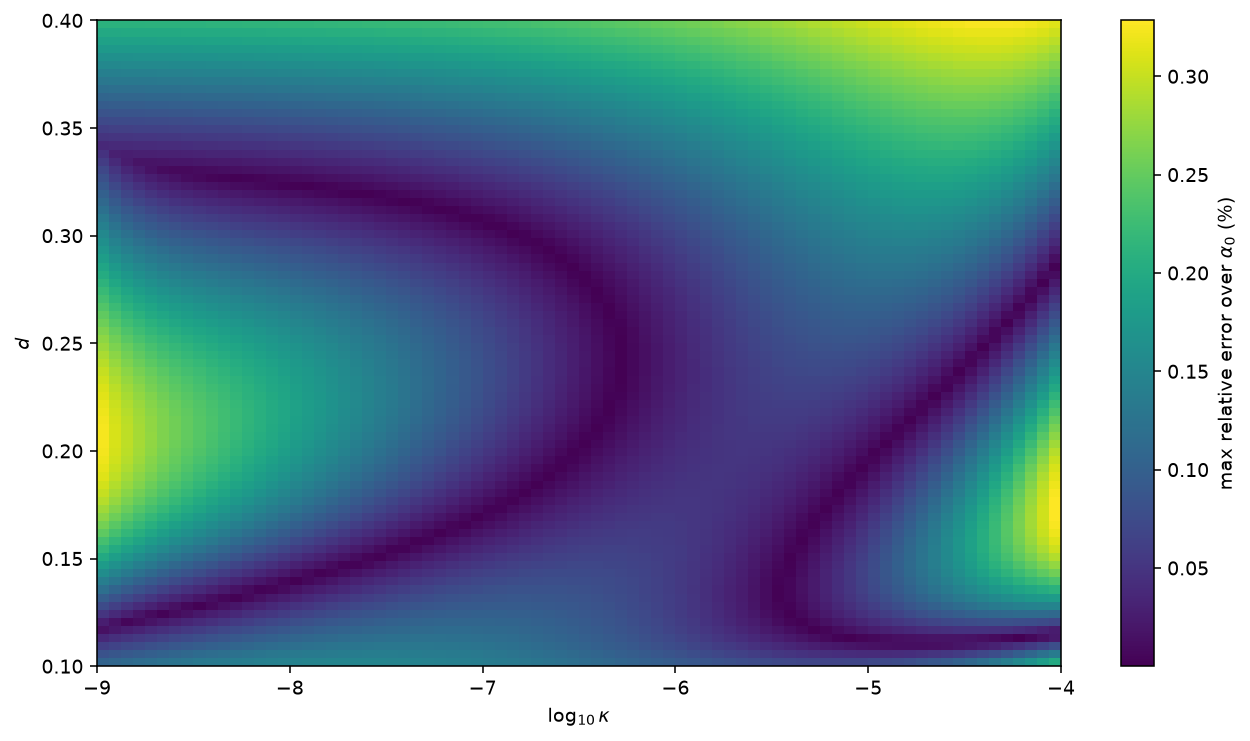

In [6]:
def plot_full_grid_loss_heatmap(part, output_path=None):
    pair_loss = pair_loss_table(part)
    grid = pair_loss.pivot(index="d", columns="log10_kappa", values="loss_percent")
    fig, ax = plt.subplots(figsize=(9.5, 5.4), dpi=140)
    im = ax.imshow(grid.to_numpy(), origin="lower", aspect="auto",
                   extent=[grid.columns.min(), grid.columns.max(), grid.index.min(), grid.index.max()])
    fig.colorbar(im, ax=ax).set_label("max relative error over $\\alpha_0$ (%)")
    ax.set_xlabel(r"$\log_{10}\kappa$"); ax.set_ylabel(r"$d$")
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, bbox_inches="tight")
    return fig, ax


fig, ax = plot_full_grid_loss_heatmap(df, output_path="full_loss.png")
plt.show()